# M2A1 - Detecção e Extração de Características

Na prática de hoje vamos utilizar [OpenCV](https://opencv.org/) para extrair características de imagens.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Extração de Caracteísticas
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install opencv-python

zsh:1: command not found: pip


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
image = cv2.imread("../assets/modulo2/1.jpeg")

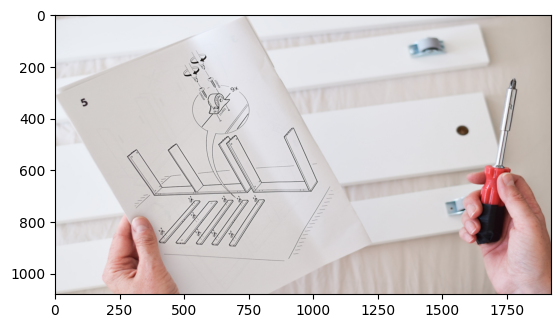

In [4]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Extração de Caracteísticas

Agora podemos criar o extrator e aplicar ele. Por exemplo o [SIFT](https://www.cs.ubc.ca/~lsigal/425_2024W1/ijcv04.pdf).

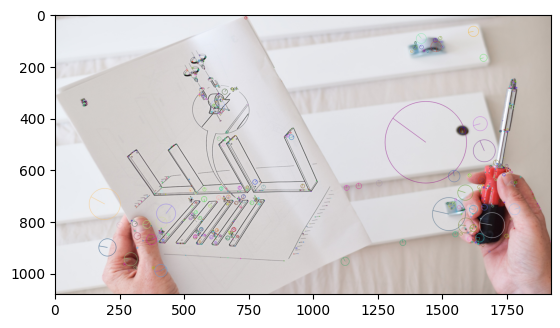

In [5]:
# Criando o detector do SIFT.
sift = cv2.SIFT_create()

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = sift.detectAndCompute(image, None)

# Visualizando os ketypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))

OpenCV também implementa outros detectores como o [ORB](https://par.cse.nsysu.edu.tw/resource/paper/2016/161129/ORB-an%20efficient%20alternative%20to%20SIFT%20or%20SURF.pdf).

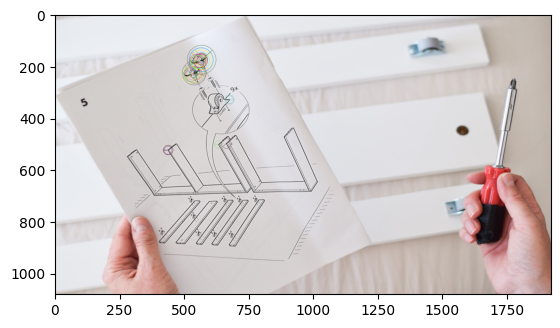

In [6]:
# Criando o detector do ORB.
orb = cv2.ORB_create(30)

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = orb.detectAndCompute(image, None)

# Visualizando os keypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))

E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremos utilizar essas características para encontrar correspondências em imagens.

Uma lista não exaustiva de referências segue:

- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [x] Leia a imagem e rode todos os comandos.
- [x] Existe alguma forma de melhorar os resutlados do SIFT?
- [x] Existem outros detectores já implementados pela OpenCV?

### Atividade 2 — Melhorando os resultados do SIFT

O SIFT tem alguns parâmetros que controlam quantos e quais keypoints são retornados:

- **nfeatures**: número máximo de features (0 = sem limite)
- **contrastThreshold**: filtra regiões com baixo contraste — valores menores detectam mais keypoints
- **edgeThreshold**: filtra keypoints em bordas — valores maiores retêm mais

Abaixo comparo o resultado padrão com parâmetros ajustados pra ver o impacto na detecção.

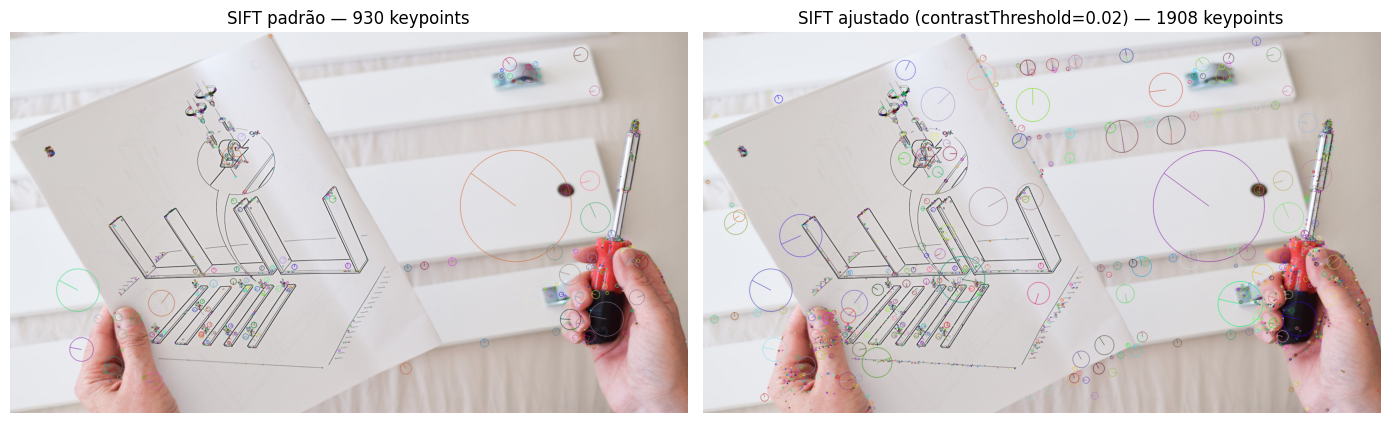

In [7]:
# SIFT padrão
sift_default = cv2.SIFT_create()
kp_default, _ = sift_default.detectAndCompute(image, None)

# Baixar o contrastThreshold faz o SIFT aceitar regiões com menos contraste,
# detectando mais keypoints. edgeThreshold maior retém mais bordas.
sift_tuned = cv2.SIFT_create(nfeatures=0, contrastThreshold=0.02, edgeThreshold=20)
kp_tuned, _ = sift_tuned.detectAndCompute(image, None)

img_default = cv2.drawKeypoints(image, kp_default, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_tuned = cv2.drawKeypoints(image, kp_tuned, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(img_default, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"SIFT padrão — {len(kp_default)} keypoints")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_tuned, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"SIFT ajustado (contrastThreshold=0.02) — {len(kp_tuned)} keypoints")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Atividade 3 — Outros detectores no OpenCV

Além do SIFT e ORB, o OpenCV implementa vários outros detectores. Testei três:

- **AKAZE**: descritor binário moderno, robusto e eficiente — boa alternativa ao SIFT sem precisar de GPU
- **BRISK**: também binário, muito rápido, com abordagem de escala diferente do ORB
- **FAST**: extremamente rápido pra tempo real, mas só detecta pontos sem calcular escala ou orientação

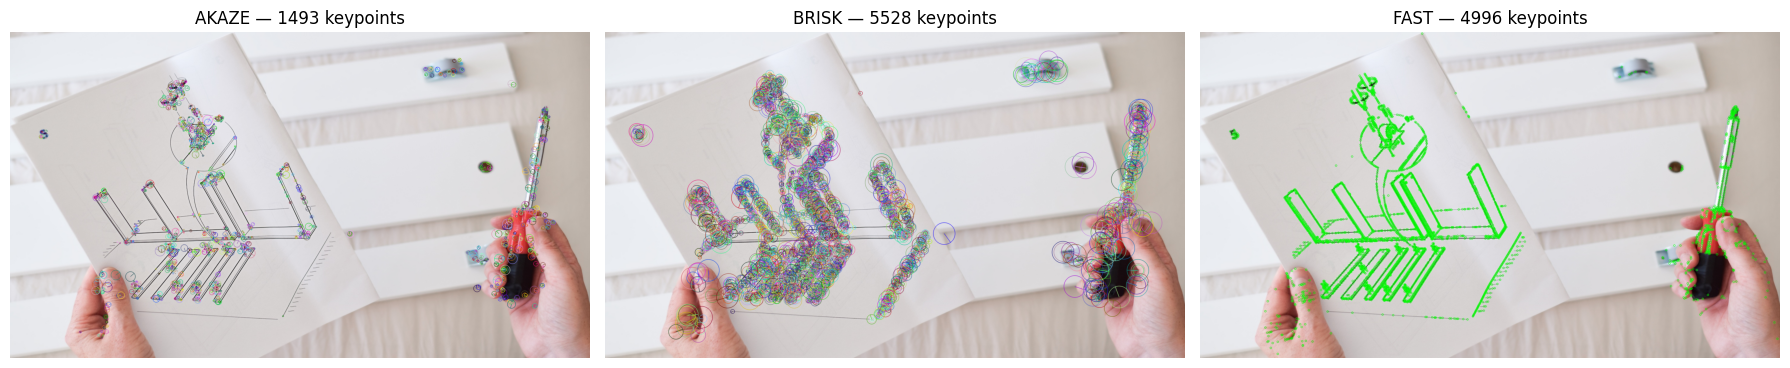

In [8]:
akaze = cv2.AKAZE_create()
kp_akaze, _ = akaze.detectAndCompute(image, None)
img_akaze = cv2.drawKeypoints(image, kp_akaze, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

brisk = cv2.BRISK_create()
kp_brisk, _ = brisk.detectAndCompute(image, None)
img_brisk = cv2.drawKeypoints(image, kp_brisk, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# FAST só detecta pontos, não computa descritores nem escala/orientação
fast = cv2.FastFeatureDetector_create()
kp_fast = fast.detect(image, None)
img_fast = cv2.drawKeypoints(image, kp_fast, None, color=(0, 255, 0))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img_kp, title, kp in zip(
    axes,
    [img_akaze, img_brisk, img_fast],
    ["AKAZE", "BRISK", "FAST"],
    [kp_akaze, kp_brisk, kp_fast],
):
    ax.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title} — {len(kp)} keypoints")
    ax.axis("off")
plt.tight_layout()
plt.show()